In [20]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as cx

In [21]:
url = "https://data.cityofnewyork.us/api/views/2pg3-gcaa/rows.csv?accessType=DOWNLOAD"
df = pd.read_csv(url)

print(df.shape)
df.head()

(780, 43)


,Title,Alternate Title,Primary Artist Last,Primary Artist First,Primary Artist Middle,Secondary Artist Last,Secondary Artist First,Secondary Artist Middle,Artists Keyword,Primary Architect Last,...,Borough,Subject Keyword,Inscription,Managing City Agency,Acquisition,PDC Records,Latitude,Longitude,Block,Lot #
0,Column of Jerash,Whispering Column of Jerash,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Queens,"1964-65 World's Fair, antiquity",THIS COLUMN WAS PRESENTED TO/ THE NEW YORK WOR...,Department of Parks and Recreation,Gift of King Hussein of Jordan,NaN,40.746509,-73.842321,2018,1.0
1,Amiable Child Memorial,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Manhattan,"Children, tomb",West side of pedestal: ERECTED TO THE MEMORY /...,Department of Parks and Recreation,NaN,NaN,"40.814761,",-73.963162,1897,1.0
2,Fort George Memorial Tablet,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Manhattan,American Revolutionary War,TO PERPETUATE / THE SITE OF THE S.W. BASTION O...,Department of Parks and Recreation,Gift of the Corporation of the City of New York,NaN,40.703913,-74.014488,3,1.0
3,Firemen's Memorial,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Manhattan,Firefighters,THIS MONUMENT IS ERECTED / BY THE MEMBERS OF /...,Department of Parks and Recreation,Gift of Eagle Fire Company and Friends,2252,40.730092,-74.006382,582,1.0
4,Madison Square Fountain,Southern Fountain,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Manhattan,Fountain,THIS FOUNTAIN ORIGINALLY STOOD ON SITE OF OLD ...,Department of Parks and Recreation,NaN,1945,40.741722,-73.988297,852,1.0


### Choosing attributes to explore

After looking at the dataset's metadata, I decided to focus on **Material**, **Artwork 
Type**, and **Borough**. These three stood out because together they let me explore both 
the physical character of NYC's public art (what it's made of, what form it takes) and 
how that character is distributed geographically across the city.

Looking at the raw value counts above, both `Material` and `Artwork Type1` turned out to 
be very messy: many entries are highly specific, one-off combinations (e.g. "Acrylic 
resin, steel, motors, LED lights"), which would make for an unreadable map legend or 
chart with 100+ categories. Rather than drop these attributes, I grouped them into a 
smaller number of broader, meaningful categories (see the next two cells) so patterns 
across the city become visible without losing the core information.

I chose *not* to focus on attributes like Artist name or Inscription text, since those 
are highly individual to each piece and don't lend themselves to meaningful aggregation 
or comparison across the city the way Material, Type, and Borough do.

In [22]:
print(df["Artwork Type1"].value_counts())
print()
print(df["Material"].value_counts())
print()
print(df["Borough"].value_counts())

Artwork Type1
Statue                                     137
Plaque                                     113
Sculpture                                   84
Bas-relief                                  41
Plaque, plinth                              30
                                          ... 
Landscape installation                       1
Installation, mosaic                         1
Decorative paving, stone seating, fence      1
Sculpture, engraved paving                   1
Railing, marker                              1
Name: count, Length: 134, dtype: int64

Material
Bronze, granite                             159
Bronze                                       95
Granite                                      64
Indiana limestone                            34
Marble                                       21
                                           ... 
Acrylic resin, steel, motors, LED lights      1
Stainless steel, reclaimed wood, acrylic      1
Granite, limestone, bronze          

In [23]:
def simplify_material(val):
    if pd.isna(val):
        return "Unknown"
    val = val.lower()
    if "bronze" in val:
        return "Bronze"
    elif "granite" in val:
        return "Granite"
    elif "marble" in val:
        return "Marble"
    elif "limestone" in val:
        return "Limestone"
    elif "steel" in val or "iron" in val or "metal" in val:
        return "Steel/Iron"
    elif "stone" in val:
        return "Stone (other)"
    else:
        return "Other"


df["Material_Simple"] = df["Material"].apply(simplify_material)
print(df["Material_Simple"].value_counts())

Material_Simple
Bronze           479
Granite          120
Steel/Iron        52
Limestone         39
Other             33
Marble            30
Stone (other)     25
Unknown            2
Name: count, dtype: int64


In [24]:
def simplify_type(val):
    if pd.isna(val):
        return "Unknown"
    val = val.lower()
    if "statue" in val:
        return "Statue"
    elif "plaque" in val:
        return "Plaque"
    elif "sculpture" in val:
        return "Sculpture"
    elif "bas-relief" in val or "relief" in val:
        return "Bas-relief"
    elif "fountain" in val:
        return "Fountain"
    elif "mural" in val:
        return "Mural"
    else:
        return "Other"


df["Type_Simple"] = df["Artwork Type1"].apply(simplify_type)
print(df["Type_Simple"].value_counts())

Type_Simple
Plaque        212
Other         199
Statue        155
Sculpture      98
Bas-relief     74
Fountain       35
Mural           7
Name: count, dtype: int64


In [25]:
print(geo_df["Latitude"].dtype)
print(geo_df["Longitude"].dtype)
print(geo_df[["Latitude", "Longitude"]].head(10))

float64
float64
    Latitude  Longitude
0  40.746509 -73.842321
1  40.814761 -73.963162
2  40.703913 -74.014488
3  40.730092 -74.006382
4  40.741722 -73.988297
5  40.772435 -73.972532
6  40.735370 -73.990703
7  40.742745 -73.988969
8  40.773185 -73.971735
9  40.763383 -73.830149


In [31]:
# Clean Latitude/Longitude: strip stray characters, convert to numeric
geo_df = df.copy()

geo_df["Latitude"] = pd.to_numeric(
    geo_df["Latitude"].astype(str).str.replace(",", "", regex=False).str.strip(),
    errors="coerce",
)
geo_df["Longitude"] = pd.to_numeric(
    geo_df["Longitude"].astype(str).str.replace(",", "", regex=False).str.strip(),
    errors="coerce",
)

geo_df = geo_df.dropna(subset=["Latitude", "Longitude"]).reset_index(drop=True)

# Filter to a tighter NYC-only bounding box (excludes NJ, LI, etc.)
geo_df = geo_df[
    (geo_df["Latitude"].between(40.49, 40.92))
    & (geo_df["Longitude"].between(-74.26, -73.68))
].reset_index(drop=True)

print(geo_df.shape)

gdf = gpd.GeoDataFrame(
    geo_df,
    geometry=gpd.points_from_xy(geo_df["Longitude"], geo_df["Latitude"]),
    crs="EPSG:4326",
)

gdf.shape

(764, 45)


(764, 46)

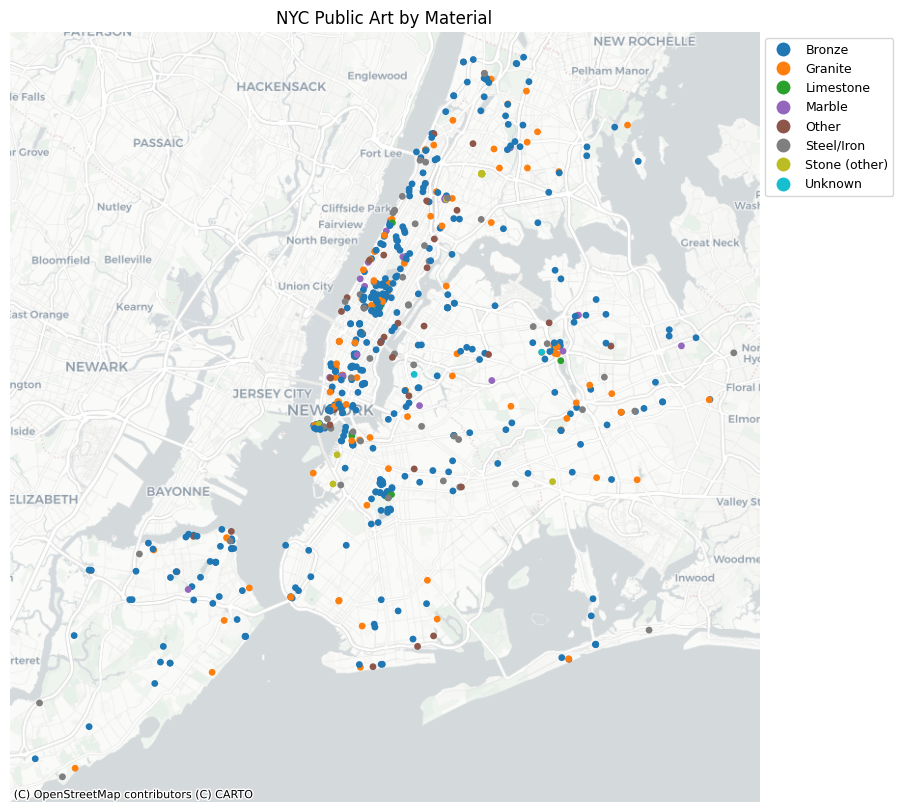

In [32]:
gdf_web = gdf.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(10, 10))
gdf_web.plot(
    ax=ax,
    column="Material_Simple",
    categorical=True,
    legend=True,
    markersize=15,
    legend_kwds={"loc": "upper left", "bbox_to_anchor": (1, 1), "fontsize": 9},
)

minx, miny, maxx, maxy = gdf_web.total_bounds
buffer = 2000
ax.set_xlim(minx - buffer, maxx + buffer)
ax.set_ylim(miny - buffer, maxy + buffer)

cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)

ax.set_title("NYC Public Art by Material")
ax.set_axis_off()
plt.show()

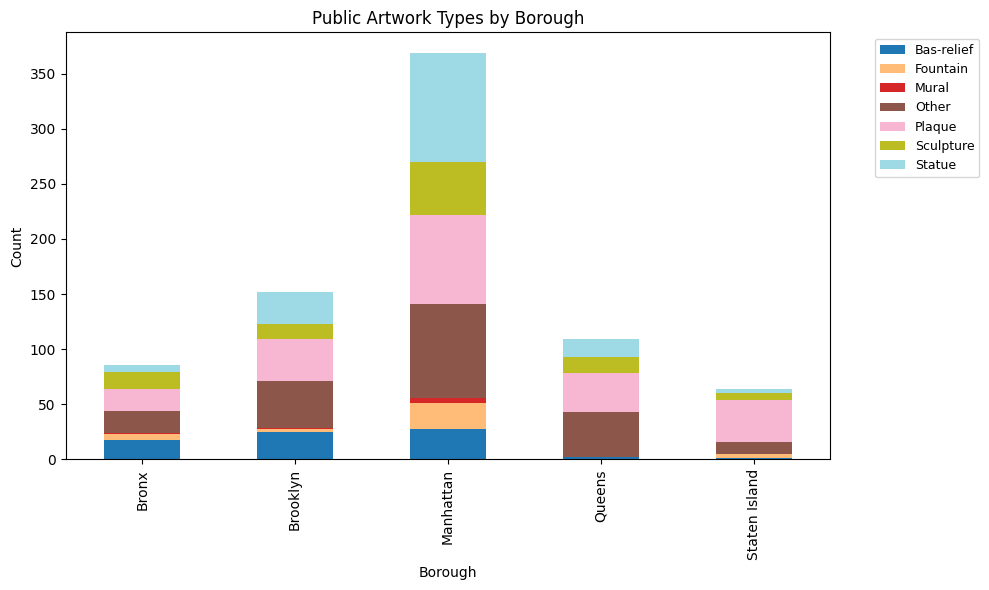

In [28]:
type_borough = df.groupby(["Borough", "Type_Simple"]).size().unstack(fill_value=0)

type_borough.plot(kind="bar", stacked=True, figsize=(10, 6), colormap="tab20")
plt.title("Public Artwork Types by Borough")
plt.ylabel("Count")
plt.xlabel("Borough")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

## Interpretation

**Why these attributes:** I chose to look at *Material* and *Artwork Type*, broken down 
by *Borough*, because they reveal both the physical/aesthetic character of NYC's public 
art and how it's distributed across the city. Material tells us what the artworks are 
literally made of: durability, cost, and craftsmanship all show up here. Artwork Type 
tells us what kind of art the city has installed, whether memorial, decorative, or 
functional pieces like fountains.

**What the map shows:** Bronze is overwhelmingly the dominant material citywide, followed 
by granite. This likely reflects that a large share of the dataset is monuments and 
memorials, which are traditionally cast in bronze for durability and historical convention. 
The spatial spread of points roughly traces the shape of the five boroughs, with dense 
clusters in Manhattan and along major public spaces (parks, civic centers).

**What the bar chart shows:** Manhattan has by far the most public art (about 370 pieces), 
more than double any other borough, driven especially by statues and a large "Other" 
category. Brooklyn comes next (about 150), followed by Queens and Staten Island at similar, 
lower levels, with the Bronx lowest overall. Plaques are common across every borough, 
but statues and sculptures skew heavily toward Manhattan and Queens. Fountains and murals 
are rare citywide, a reminder that this dataset leans toward permanent, monument-style 
artworks rather than more experimental or temporary public art forms.

**What these attributes can't tell us:** Material and type don't capture the artistic or 
cultural significance of a piece; a small bronze plaque and a monumental bronze statue 
are counted the same way. The concentration in Manhattan may partly reflect where the 
Public Design Commission has historically been most active (civic and cultural centers), 
not necessarily where the most meaningful art exists. The dataset also only includes 
outdoor, City-owned artworks on public property, so it misses private art, indoor museum 
collections, and temporary installations like murals or street art, which would tell a 
very different story about NYC's art landscape. Finally, some rows were dropped due to 
missing or malformed coordinates, meaning the map likely underrepresents the true scope 
of the collection.